## Grid points

`grid_points` plots the **centroid location** of every grid cell as a uniform dot on the map. Unlike `point_cloud`, it does not colour the points by data value — all dots are drawn in the same colour. This makes it a diagnostic tool rather than a data visualisation:

- inspect the **density and distribution** of a grid before plotting data on it,
- verify that the correct grid is being used (especially when metadata may be missing or overridden),
- overlay grid point positions on top of a coloured field for context.

Because `grid_points` ignores style, levels and units arguments, it is much faster than `point_cloud` for large grids.

### Example: inspecting a HEALPix grid

We load a HEALPix GRIB file and plot only the centroid locations, with no data values shown.

healpix-h128-nested-2t.grib:   0%|          | 0.00/385k [00:00<?, ?B/s]

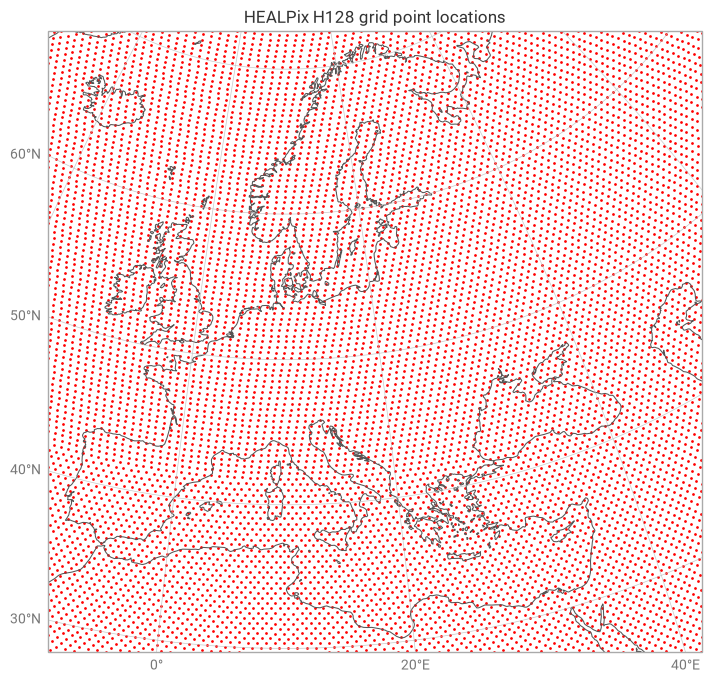

In [1]:
import earthkit.data as ekd

import earthkit.plots as ekp

data = ekd.from_source("sample", "healpix-h128-nested-2t.grib")

chart = ekp.Map(domain="Europe")

chart.grid_points(data)

chart.coastlines()
chart.gridlines()
chart.title("HEALPix H128 grid point locations")

chart.show()

### Customising the markers

Any matplotlib `scatter` keyword argument can be passed to control the appearance of the points: `color`, `s` (size), `marker`, `alpha`, etc.

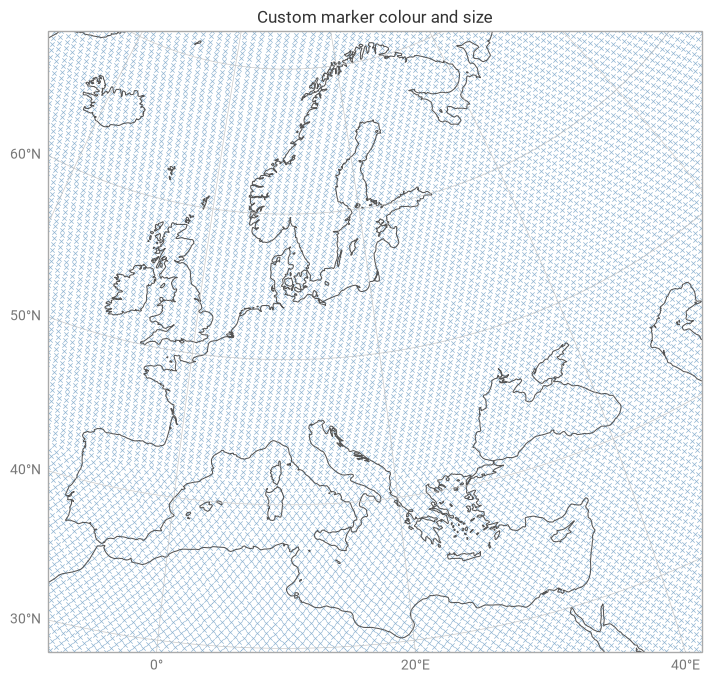

In [2]:
chart = ekp.Map(domain="Europe")

chart.grid_points(data, c="steelblue", marker="x", s=10, alpha=0.6)

chart.coastlines()
chart.gridlines()
chart.title("Custom marker colour and size")

chart.show()

### Comparing two grids side by side

A common use case is comparing the grid structure of two different datasets — for example, a nested-ordering HEALPix grid vs. a ring-ordering one of the same resolution.

healpix-h128-nested-2t.grib:   0%|          | 0.00/385k [00:00<?, ?B/s]

healpix-h128-ring-2t.grib:   0%|          | 0.00/385k [00:00<?, ?B/s]

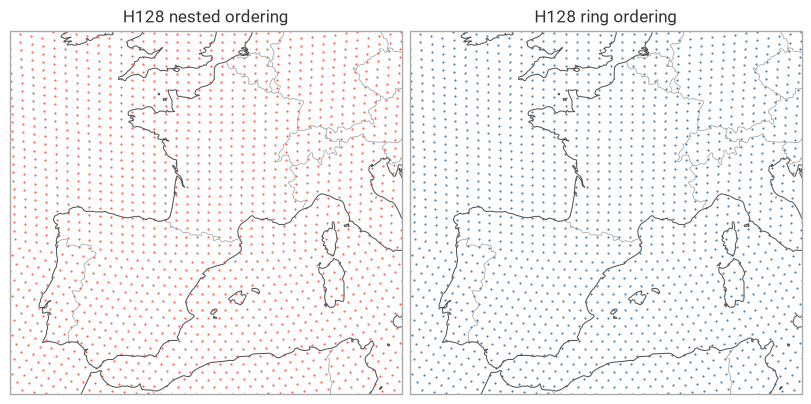

In [3]:
nested = ekd.from_source("sample", "healpix-h128-nested-2t.grib")
ring = ekd.from_source("sample", "healpix-h128-ring-2t.grib")

figure = ekp.Figure(rows=1, columns=2, domain=["France", "Spain"])

ax = figure.add_map()
ax.grid_points(nested, s=4, c="tomato")
ax.title("H128 nested ordering")

ax = figure.add_map()
ax.grid_points(ring, s=4, c="steelblue")
ax.title("H128 ring ordering")

figure.coastlines()
figure.borders()

figure.show()

<div class="alert alert-block alert-info">
<strong>NOTE:</strong> <code>grid_points</code> silently ignores <code>style</code>, <code>levels</code>, <code>units</code> and <code>colors</code> arguments — it always draws uniform markers. To colour points by data value, use <code>point_cloud</code> instead.
</div>